## Actividad 1: Exploración y preprocesamiento de datos

---
En esta actividad se realiza un análisis exploratorio de un conjunto de datos de estaciones de servicio, con el objetivo de estudiar el comportamiento de los precios de carburante y preparar los datos para su uso en modelos de aprendizaje automático.

Se utilizan herramientas como pandas, matplotlib, scikit-learn y AutoViz para llevar a cabo el análisis, la visualización y el preprocesamiento de los datos.

**Autora:**
 👨‍💻    [Anabel Díaz](https://github.com/rubiwan)

### 1. Carga de datos
---
Se carga el conjunto de datos en un DataFrame utilizando la librería pandas. Este dataset contiene información sobre estaciones de servicio, incluyendo ubicación, tipo de servicio y precios de carburante.

In [1]:
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler


df = pd.read_csv("gii32_ act1_precios_carburantes_24.csv")
df.head()

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
0,ALBACETE,ABENGIBRE,ABENGIBRE,2250,"AVENIDA CASTILLA LA MANCHA, 26","1,529","1,419",P,A,Nº 10.935
1,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 5",NaN,"1,560",R,A,CEPSA
2,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 1","1,409","1,399",P,D,PLENOIL
3,ALBACETE,ALBACETE,ALBACETE,2001,"AVENIDA 1º DE MAYO, S/N","1,539","1,489",P,A,CARREFOUR
4,ALBACETE,ALBACETE,ALBACETE,2001,CALLE PRINCIPE DE ASTURIAS (POLÍGONO DE ROMICA...,"1,549","1,549",P,A,BP ROMICA


### 2. Exploración inicial de los datos
---
Se realiza un análisis preliminar del dataset para conocer su estructura, número de registros, tipos de datos y distribución de los valores.
#### 2.1. Estructura del dataset
Extraemos el número de filas y columnas para entender la dimensión del conjunto de datos.

In [2]:
df.shape

(11865, 10)

#### 2.2. Nombre de columnas
Observamos que incluye columnas relacionadas con la ubicación (Provincia, Municipio), tipo de servicio, código postal y precios de carburante (Precio gasolina 95 E5, Precio gasóleo A).

In [3]:
df.columns

Index(['Provincia', 'Municipio', 'Localidad', 'Código postal', 'Dirección',
       'Precio gasolina 95 E5', 'Precio gasóleo A', 'Tipo venta',
       'Tipo servicio', 'Rótulo'],
      dtype='object')

#### 2.3. Tipos de datos
- Se observa que el dataset contiene variables categóricas (Provincia, Municipio, Tipo de servicio, etc.) y variables numéricas.
- Sin embargo, los precios de carburante están almacenados como texto debido al uso de la coma como separador decimal, lo que requerirá un preprocesamiento posterior.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11865 entries, 0 to 11864
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Provincia              11865 non-null  object
 1   Municipio              11865 non-null  object
 2   Localidad              11865 non-null  object
 3   Código postal          11865 non-null  int64 
 4   Dirección              11865 non-null  object
 5   Precio gasolina 95 E5  10702 non-null  object
 6   Precio gasóleo A       11498 non-null  object
 7   Tipo venta             11865 non-null  object
 8   Tipo servicio          10803 non-null  object
 9   Rótulo                 11865 non-null  object
dtypes: int64(1), object(9)
memory usage: 927.1+ KB


#### 2.4. Resumen estadístico

In [5]:
df.describe(include='all')

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
count,11865,11865,11865,11865.000000,11865,10702,11498,11865,10803,11865
unique,52,3415,4228,NaN,11554,414,438,3,3,4025
top,MADRID,MADRID,MADRID,NaN,"AVENIDA ANDALUCIA, S/N","1,559","1,569",P,A,REPSOL
freq,852,241,241,NaN,11,568,642,11105,8098,2733
mean,NaN,NaN,NaN,25413.898272,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,14476.124512,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1002.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,12006.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,27246.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,38002.000000,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Nuevo dataset para análisis de precios
---
#### 3.1. Filtrado por provincia.
Se selecciona la provincia de Madrid para el análisis, ya que presenta un número elevado de registros, lo que permite realizar un estudio más representativo de los precios de carburante. Creamos un nuevo DataFrame:

In [6]:
df_madrid = df[df['Provincia'] == 'MADRID']
df_madrid.head()

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
6484,MADRID,AJALVIR,AJALVIR,28864,CARRETERA M-114 KM. 1,"1,599","1,579",P,A,REPSOL
6485,MADRID,AJALVIR,AJALVIR,28864,"CARRETERA M-114 KM. 0,7","1,599","1,579",P,A,REPSOL
6486,MADRID,AJALVIR,AJALVIR,28864,"CAMINO TORREJON, 4","1,479","1,389",P,D,PLENOIL
6487,MADRID,ÁLAMO (EL),ALAMO (EL),28607,"CTRA. LOCAL M-404 km 3,640","1,464","1,339",P,A,"E.S. EL ALAMO, S.L."
6488,MADRID,ÁLAMO (EL),ALAMO (EL),28607,"AVENIDA MADRID, 2","1,459","1,349",P,D,PLENOIL


#### 3.2. Verificación de columnas después del filtrado.
Confirmamos que el nuevo DataFrame, df_madrid, contiene las mismas columnas que el dataset original, lo que garantiza que no se han perdido atributos importantes durante el proceso de filtrado.

In [7]:
df_madrid.columns

Index(['Provincia', 'Municipio', 'Localidad', 'Código postal', 'Dirección',
       'Precio gasolina 95 E5', 'Precio gasóleo A', 'Tipo venta',
       'Tipo servicio', 'Rótulo'],
      dtype='object')

#### 3.3. Verificación de tamaño del nuevo DataFrame.

In [8]:
df_madrid.shape

(852, 10)

#### 3.4. Selección de variables relevantes - Análisis de precios.
Se seleccionan las variables correspondientes a los precios de gasolina 95 y gasóleo A, ya que son las más relevantes para el análisis comparativo del dataset.

In [9]:
df_precios = df_madrid[['Precio gasolina 95 E5', 'Precio gasóleo A']].copy()

### 4. Preprocesamiento de datos
---
#### 4.1. Reemplazamos las comas por los puntos.
Reemplazamos las comas por puntos en las columnas de precios para convertir los valores a un formato numérico adecuado para su análisis y modelado. Este paso es esencial para garantizar que los precios se interpreten correctamente como números decimales en lugar de texto.

In [10]:
df_precios['Precio gasolina 95 E5'] = df_precios['Precio gasolina 95 E5'].str.replace(',', '.')
df_precios['Precio gasóleo A'] = df_precios['Precio gasóleo A'].str.replace(',', '.')

#### 4.2. Conversión del tipo de datos
Después de reemplazar las comas por puntos, convertimos las columnas de precios a tipo numérico (float) para permitir el análisis estadístico y la aplicación de técnicas de aprendizaje automático en el futuro. Esta conversión es crucial para asegurar que los datos se manejen correctamente en cálculos y visualizaciones posteriores.

In [11]:
df_precios['Precio gasolina 95 E5'] = df_precios['Precio gasolina 95 E5'].astype(float)
df_precios['Precio gasóleo A'] = df_precios['Precio gasóleo A'].astype(float)

#### 4.3. Verificación de tipos de datos después de la conversión.
Confirmamos que las columnas de precios han sido convertidas correctamente a tipo numérico (float), lo que nos permitirá realizar análisis estadísticos y aplicar técnicas de aprendizaje automático sin problemas relacionados con el formato de los datos.

In [12]:
df_precios.dtypes

Precio gasolina 95 E5    float64
Precio gasóleo A         float64
dtype: object

In [13]:
df_precios.head()

,Precio gasolina 95 E5,Precio gasóleo A
6484,1.599,1.579
6485,1.599,1.579
6486,1.479,1.389
6487,1.464,1.339
6488,1.459,1.349


#### 4.4. Detección y tratamiento de valores faltantes
Se identifican valores faltantes en las variables de precio. Estos valores pueden afectar al análisis y a futuros modelos de aprendizaje automático, por lo que es necesario tratarlos adecuadamente.

In [14]:
df_precios.isnull().sum()

Precio gasolina 95 E5    40
Precio gasóleo A         32
dtype: int64

#### 4.4. Imputación de datos.
- Se ha optado por realizar la imputación de valores faltantes utilizando la mediana en lugar de la media, ya que la media aritmética es sensible a valores extremos (outliers), que pueden aparecer en los precios de carburante.
- El uso de la mediana permite preservar mejor la distribución real de los datos, evitando distorsiones y manteniendo la integridad estadística del conjunto de datos.

In [15]:
imputer = SimpleImputer(strategy='median')

df_precios[['Precio gasolina 95 E5', 'Precio gasóleo A']] = imputer.fit_transform(
    df_precios[['Precio gasolina 95 E5', 'Precio gasóleo A']]
)

In [16]:
df_precios.isnull().sum()

Precio gasolina 95 E5    0
Precio gasóleo A         0
dtype: int64

#### 4.5. Guardar el dataset de precios
- Una vez realizado el preprocesamiento, se exporta el dataset limpio a un archivo CSV.
- Esto permitirá conservar los cambios realizados y facilita su uso en futuros análisis o modelos de aprendizaje automático.

In [26]:
df_precios.to_csv("precios_limpios.csv", index=False, encoding='utf-8')

### 5. Análisis estadístico descriptivo.
---
Se calculan medidas estadísticas como la media, desviación estándar, valores mínimos y máximos, lo que permite obtener una visión general del comportamiento de los precios.

In [17]:
df_precios.describe()

,Precio gasolina 95 E5,Precio gasóleo A
count,852.000000,852.000000
mean,1.561992,1.507434
std,0.072456,0.100117
min,1.389000,1.249000
25%,1.499000,1.428750
50%,1.589000,1.559000
75%,1.615000,1.579000
max,1.749000,1.709000


#### 5.1. Análisis de la distribución de precios
- Los histogramas muestran la distribución de los precios de gasolina y gasóleo.
- Observamos que los valores se concentran en intervalos específicos, lo que indica una dispersión moderada.
- Esto permite identificar patrones de comportamiento en los precios y posibles diferencias entre ambos carburantes.


#### 5.1.1. Histograma para "Precio gasolina 95 E5"

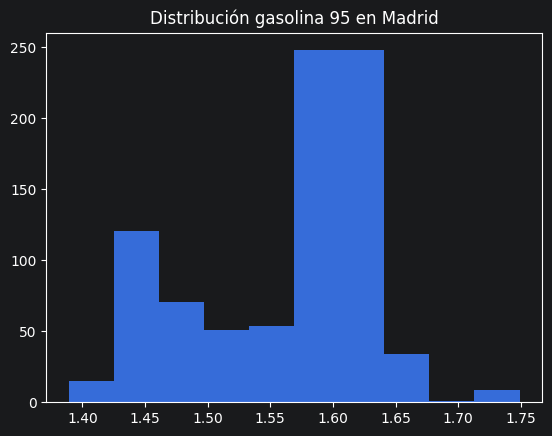

In [18]:
%matplotlib inline

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

plt.hist(df_precios['Precio gasolina 95 E5'])
plt.title("Distribución gasolina 95 en Madrid")
plt.show()

#### 5.1.2. Histograma para "Precio gasóleo A"

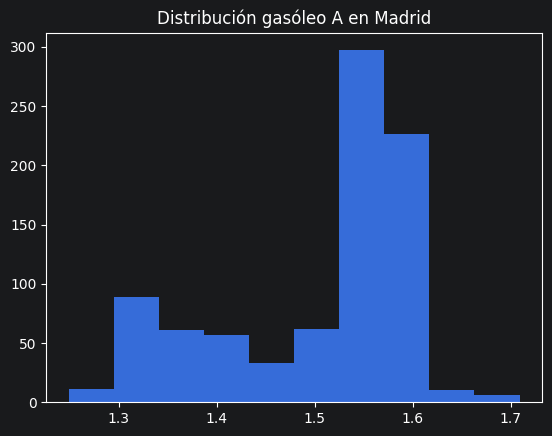

In [19]:
%matplotlib inline

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

plt.hist(df_precios['Precio gasóleo A'])
plt.title("Distribución gasóleo A en Madrid")
plt.show()

*Los histogramas obtenidos muestran la distribución de los precios, con una concentración en ciertos rangos y una dispersión moderada. El precio de la gasolina 95 parece estar más concentrado en un rango más estrecho en comparación con el gasóleo, lo que puede indicar una menor variabilidad.*

#### 5.2. Análisis de la variabilidad de precios
- El boxplot permite visualizar la mediana, el rango intercuartílico y posibles valores atípicos.
- Se observa que los precios presentan una distribución relativamente homogénea, sin presencia significativa de valores extremos.

#### 5.2.1. Boxplot for "Precio gasolina 95 E5"

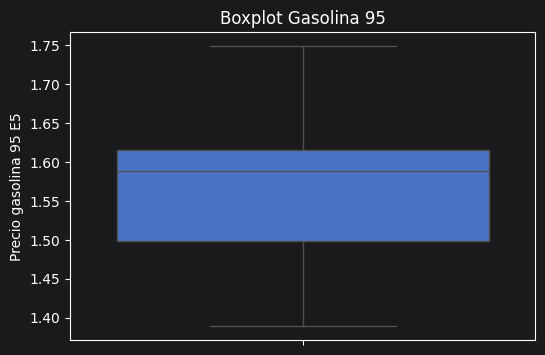

In [20]:
%matplotlib inline

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=df_precios['Precio gasolina 95 E5'])
plt.title("Boxplot Gasolina 95")
plt.show()

#### 5.2.2. Boxplot for "Precio gasóleo A"

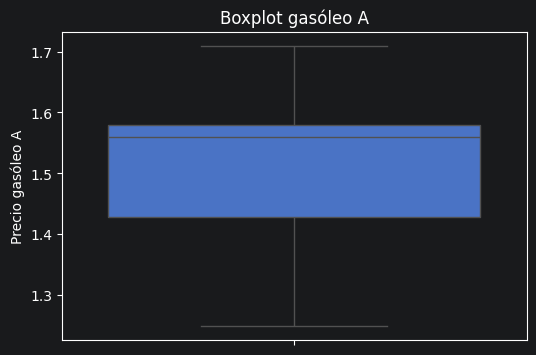

In [21]:
%matplotlib inline

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=df_precios['Precio gasóleo A'])
plt.title("Boxplot gasóleo A")
plt.show()

#### 5.2.3. Comparación entre gasolina y gasóleo

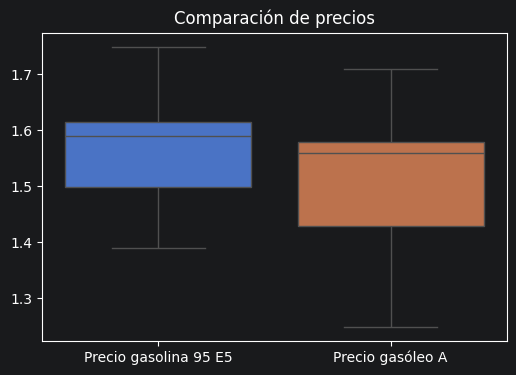

In [22]:
%matplotlib inline

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(data=df_precios[['Precio gasolina 95 E5', 'Precio gasóleo A']])
plt.title("Comparación de precios")
plt.show()

*La comparación directa entre ambas variables muestra que el precio de la gasolina es generalmente superior al del gasóleo, aunque ambas presentan una distribución similar. Esto indica que los precios siguen patrones de comportamiento parecidos.*


#### 5.3. Análisis de la correlación entre precios
- Se calcula la correlación entre las variables de precio, obteniendo una correlación positiva elevada.
- Esto indica que ambos precios tienden a variar conjuntamente: cuando aumenta el precio de la gasolina, también lo hace el del gasóleo.

In [23]:
df_precios.corr()

,Precio gasolina 95 E5,Precio gasóleo A
Precio gasolina 95 E5,1.000000,0.916998
Precio gasóleo A,0.916998,1.000000


*En este caso, la correlación es aproximadamente de 0.923, lo que indica una relación muy fuerte entre ambas variables.*

### 6. Normalización de datos
---
- Se aplica una normalización mediante MinMaxScaler, escalando los valores entre 0 y 1.
- Este proceso es fundamental en aprendizaje automático, ya que permite trabajar con variables en la misma escala y evita que unas variables tengan más peso que otras.

In [24]:
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df_precios)
df_scaled = pd.DataFrame(df_scaled, columns=df_precios.columns)



### 7. Análisis automático con AutoViz
---
- Se utiliza la herramienta AutoViz para generar automáticamente un análisis exploratorio del dataset.
- **AutoViz** permite visualizar relaciones entre variables, distribuciones y patrones de forma rápida, complementando el análisis manual realizado anteriormente.
- Los resultados obtenidos confirman las conclusiones previas, especialmente la fuerte relación entre los precios de gasolina y gasóleo.

In [25]:
from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()

df_autoviz = AV.AutoViz(
    "",
    depVar="",
    dfte=df,
    verbose=0
)

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
Shape of your Data Set loaded: (11865, 10)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    10 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
There are 122 duplicate rows in your dataset
    Alert: Dropping duplicate rows can sometimes cause your column data types to change to object!
    All variables classified into correct types.


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Provincia,object,0.000000,0,,,13 rare categories: Too many to list. Group them into a single category or drop the categories.
Municipio,object,0.000000,29,,,No issue
Localidad,object,0.000000,36,,,No issue
Código postal,int64,0.000000,38,1002.000000,52006.000000,No issue
Dirección,object,0.000000,98,,,No issue
Precio gasolina 95 E5,object,9.903772,3,,,"1163 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,, Possible high cardinality column with 414 unique values: Use hash encoding or text embedding to reduce dimension."
Precio gasóleo A,object,3.125266,3,,,"367 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,, Possible high cardinality column with 438 unique values: Use hash encoding or text embedding to reduce dimension."
Tipo venta,object,0.000000,0,,,1 rare categories: ['p']. Group them into a single category or drop the categories.
Tipo servicio,object,8.975560,0,,,"1054 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
Rótulo,object,0.000000,34,,,No issue


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package movie_reviews is a

All Plots done
Time to run AutoViz = 13 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


*Los resultados obtenidos con AutoViz confirman las conclusiones del análisis manual, identificando las variables categóricas y numéricas en el dataset, y proporcionando visualizaciones de las distribuciones y relaciones entre los atributos, reforzando la idea de que los precios de gasolina y gasóleo presentan un comportamiento similar y están fuertemente correlacionados. Esta visión general completa ayuda a validar las conclusiones extraídas del análisis exploratorio inicial y proporciona una base sólida para futuros esfuerzos de análisis y modelado.*

### 18. Dataset final para análisis y modelado
---
- El dataset final, df_scaled, contiene las variables de precio de gasolina 95 y gasóleo A normalizadas, listas para su uso en análisis adicionales o en la construcción de modelos de aprendizaje automático.
- Este dataset se puede utilizar para desarrollar modelos de regresión que predigan los precios de carburante en función de otras variables del dataset original, como la ubicación o el tipo de servicio, lo que permitiría obtener insights adicionales sobre los factores que influyen en los precios de carburante según la provincia.

In [33]:
df_scaled.head()

,Precio gasolina 95 E5,Precio gasóleo A
0,0.583333,0.717391
1,0.583333,0.717391
2,0.250000,0.304348
3,0.208333,0.195652
4,0.194444,0.217391


### Conclusion
---
- El análisis realizado muestra que los precios de gasolina y gasóleo presentan una distribución similar y una fuerte correlación positiva, lo que indica que ambas variables evolucionan de forma conjunta.
- El preprocesamiento de los datos ha permitido corregir problemas de formato y tratar valores faltantes, mejorando la calidad del dataset.
- Como posible aplicación de aprendizaje automático, se podría plantear un modelo de regresión para predecir el precio del carburante en función de variables como la provincia, el municipio, el tipo de servicio o la estación.